In [23]:
# Importing libraries
import pandas as pd
import numpy as np
from matplotlib import pyplot
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import QuantileTransformer

In [8]:
df = pd.read_csv("housing.csv")

In [9]:
housing_qt = df.copy()

In [10]:
housing_qt.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [12]:
housing_qt.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [13]:
# Drop columns you don’t want to transform (non-numeric or not useful)
columns_to_exclude = ['longitude', 'latitude', 'ocean_proximity']

In [14]:
housing_qt = housing_qt.drop(columns=columns_to_exclude)

In [15]:
housing_qt.describe()

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [17]:
# Select all remaining numeric columns automatically
columns_to_transform = housing_qt.select_dtypes(include=['int64', 'float64']).columns

In [18]:
# Initialize the QuantileTransformer
qt = QuantileTransformer(output_distribution='normal', random_state=42)

In [19]:
# Apply the transformation
housing_qt[columns_to_transform] = qt.fit_transform(housing_qt[columns_to_transform])

housing_qt.head()

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,0.901416,-1.350739,-1.694923,-1.718788,-1.644369,1.927460,1.553430
1,-0.490721,1.828444,1.472085,1.190954,1.628200,1.922705,1.196378
2,5.199338,-0.642543,-1.331018,-1.323723,-1.331018,1.634292,1.159620
3,5.199338,-0.864001,-1.048748,-1.169401,-1.068522,1.089184,1.093430
4,5.199338,-0.448671,-0.773140,-1.157879,-0.812654,0.193368,1.099399


NameError: name 'housing' is not defined

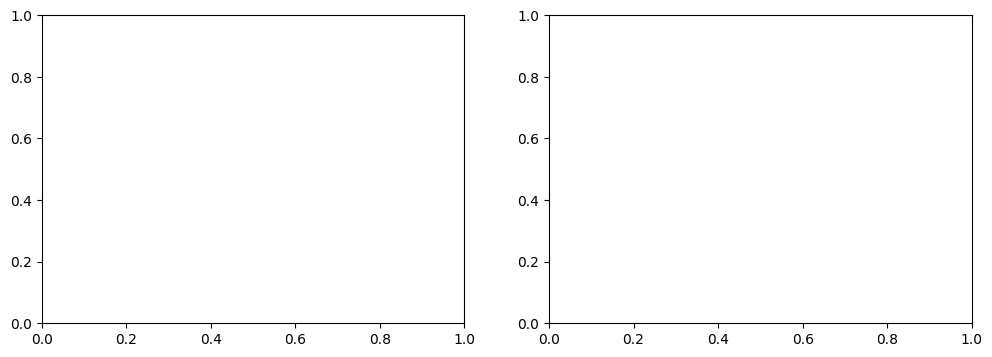

In [24]:
# Pick the variable you want to check
col = 'median_income'
# Create side-by-side histograms
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(housing[col], kde=True, ax=axs[0], color='skyblue')
axs[0].set_title(f'Original: {col}')

sns.histplot(housing_qt[col], kde=True, ax=axs[1], color='salmon')
axs[1].set_title(f'Transformed (Quantile): {col}')

plt.tight_layout()
plt.show()